In [1]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

In [4]:
kss = [
    KineticsSeries('./wt/wt.yaml', prefix='./wt'),
    KineticsSeries('./N214A/n214a.yaml', prefix='./N214A'),
    KineticsSeries('./Q256A/q256a.yaml', prefix='./Q256A'),
    KineticsSeries('./S284A/s284a.yaml', prefix='./S284A'),
]

colors = ['blue', 'teal', 'purple', 'red']

Loading: 210401_2µM_MproWT.csv...
 ... excluded
Loading: 210401_buffer_200µM_MproWT.csv...
 ... excluded
Loading: 210413_02_002µM_MproWT.csv...
 ... excluded
Loading: 210413_buffer_2µM_MproWT.csv...
 ... excluded
Loading: 210420_20µM_MproWT.csv...
 ... excluded
Loading: 210420_10µM_MproWT.csv...
 ... excluded
Loading: 210420_5_and_2µM_MproWT.csv...
 ... excluded
Loading: 210430_20_10_5_and_2µM_MproWT.csv...
Loading: 210430_buffer_160_80_and_40µM_MproWT.csv...
 ... excluding E=40.00 / S=10.00
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210507_10µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210414_20_2_02_002µM_MproN214A.csv...
 ... excluded
Loading: 210421_20_and_10_µM_MproN214A.csv...
 ... excluded
Loading: 210421_5_and_2_µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A.csv...
Loading: 210427_buffer_160_and_80µM_MproN214A_2.csv...
Loading: 210427_40_20_and_10µM_MproN214A.csv...
Loading: 210427_5_and_2µM_MproN214A.csv...
Loading:

In [3]:
ps = [5.0, 10.0, 20.0, 40.0, 80.0, 160.0]
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

n_p = len(ps)
n_s = len(ss)
print(n_p, n_s)

6 7


<IPython.core.display.Javascript object>


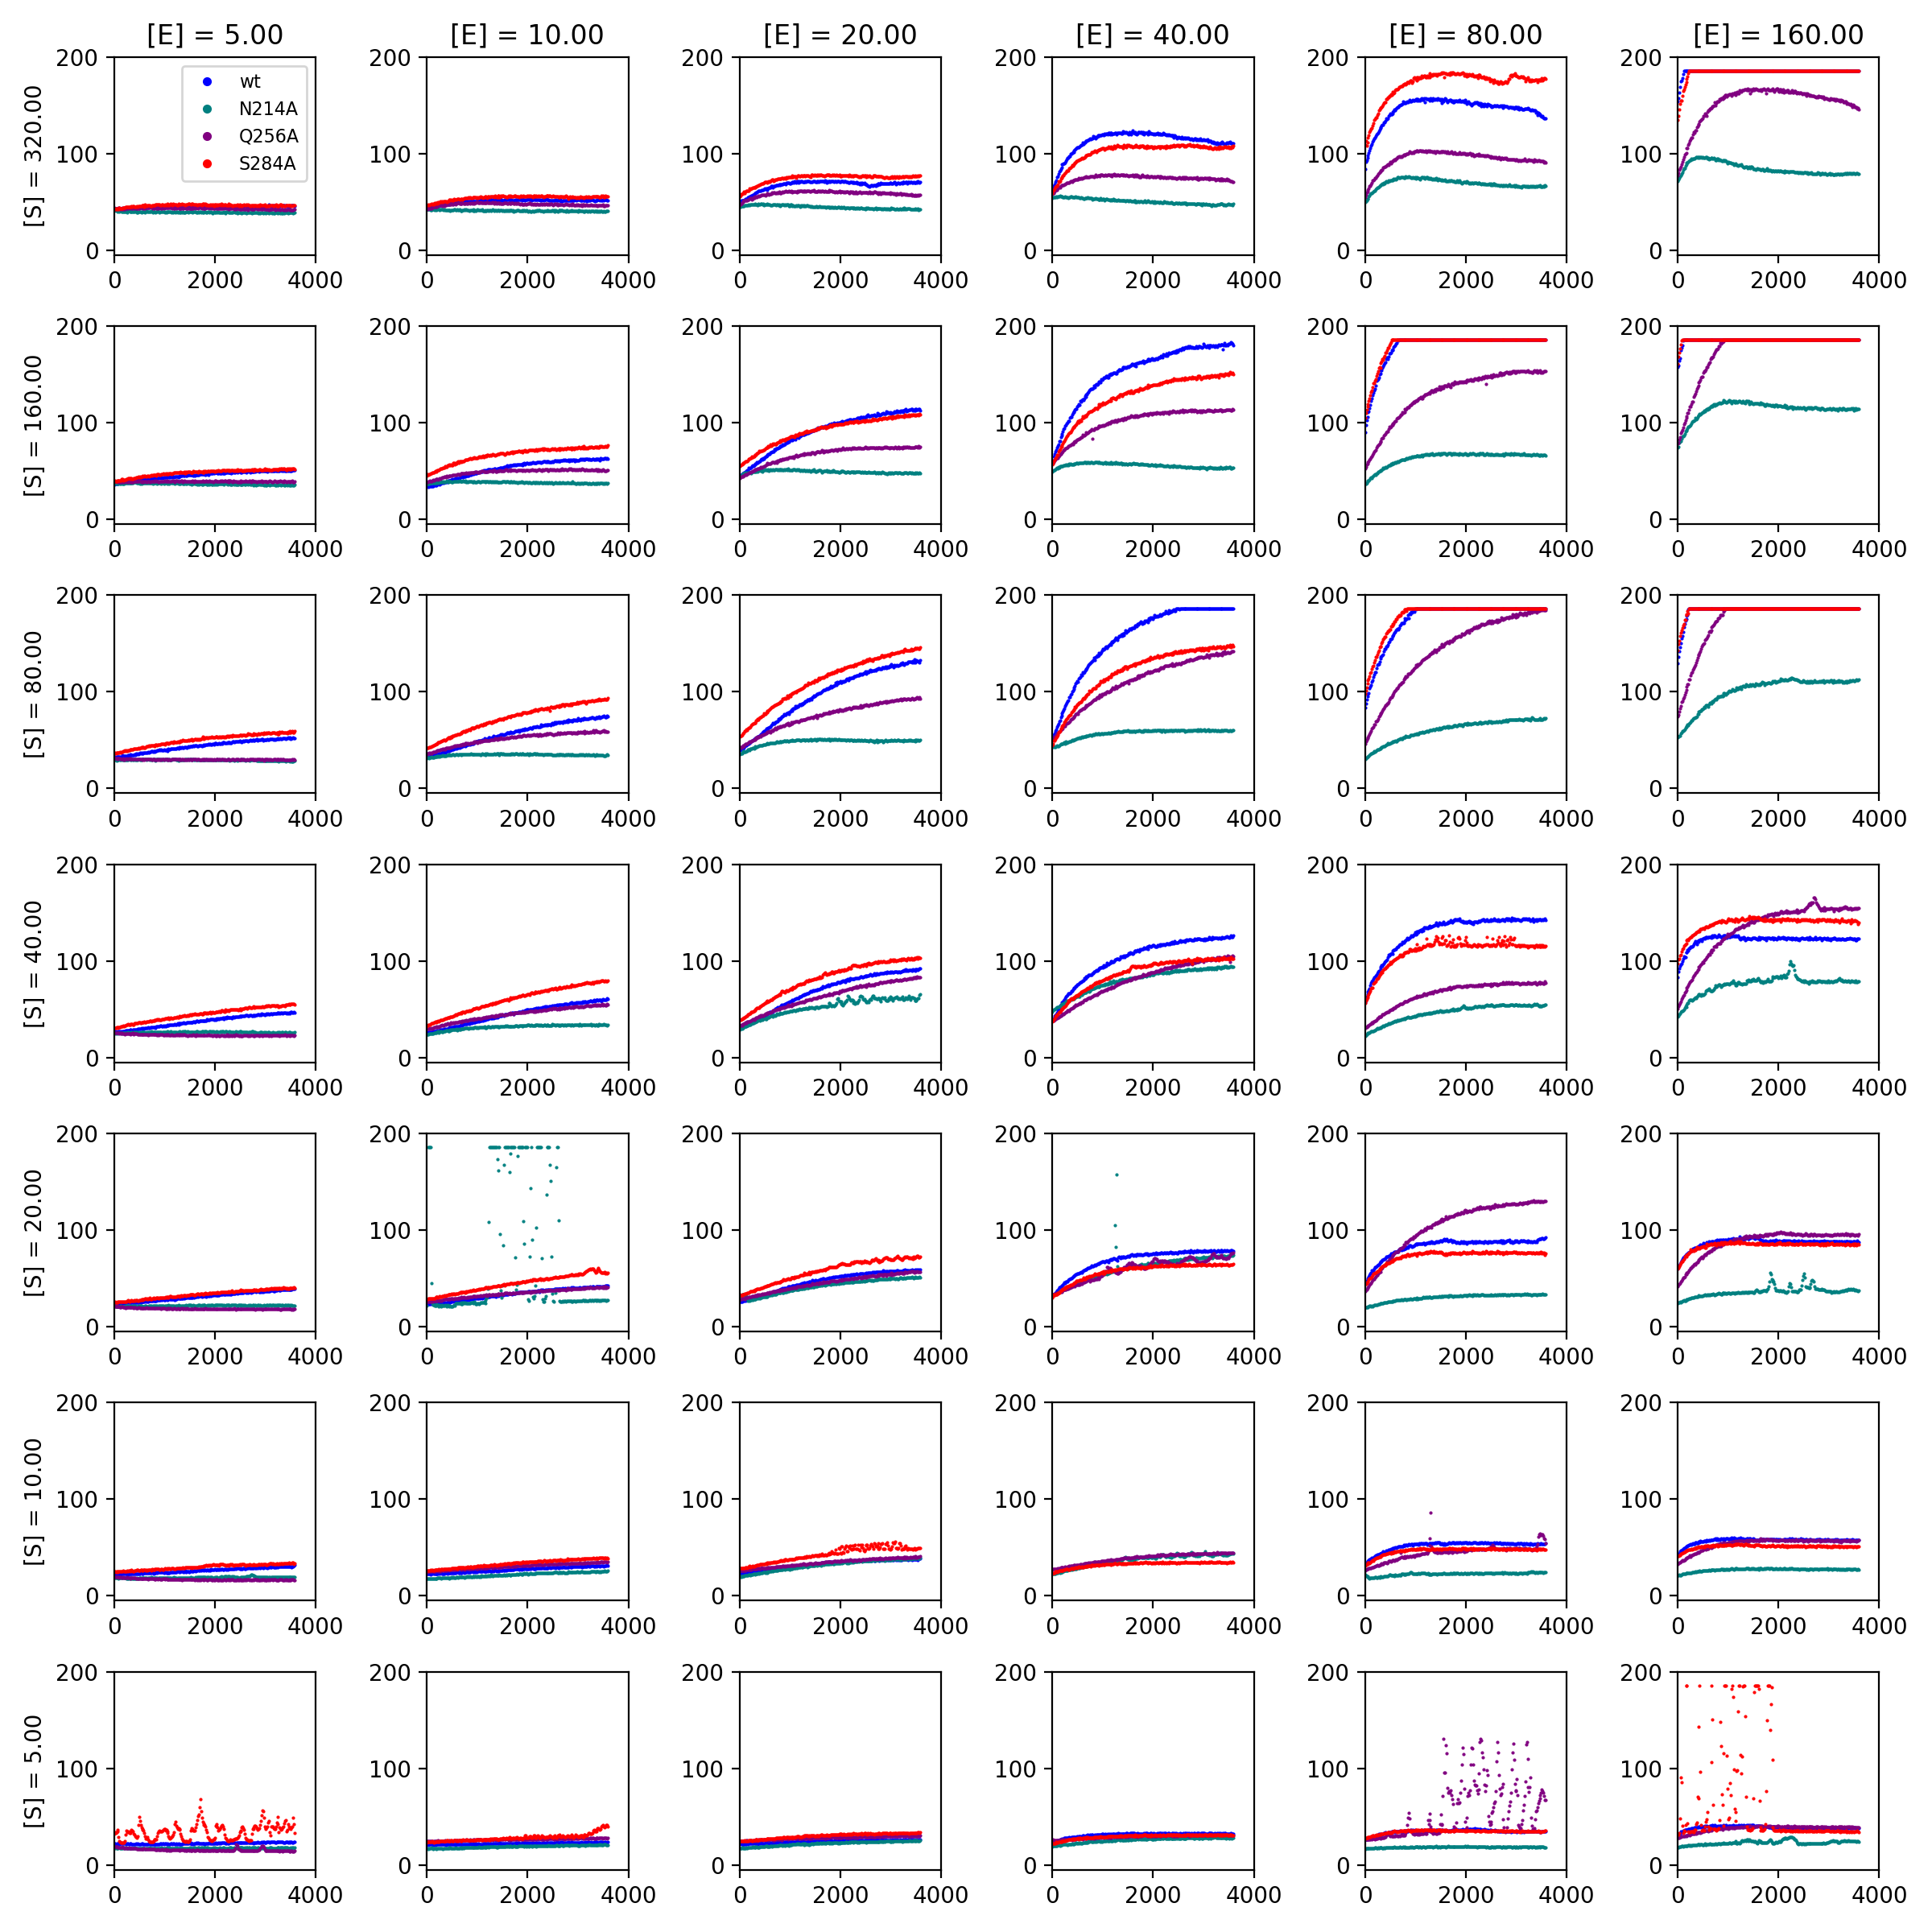

In [18]:
fig, axes = plt.subplots(n_s, n_p, figsize=(12,12))

for i_p,p in enumerate(ps):
    for i_s,s in enumerate(ss):
        
        for i_k,ks in enumerate(kss):
        
            v0_set = []

            try:
                entries = ks.get(p, s)
            except:
                print('no', p, s)
                entries = [{'exclude' : True}]

            for entry in entries:

                if i_s == 0:
                    axes[i_s, i_p].set_title('[E] = %.2f' % p)
                if i_p == 0:
                    axes[i_s, i_p].set_ylabel('[S] = %.2f' % s)

                axes[i_s, i_p].set_xlim([0, 4000])
                axes[i_s, i_p].set_ylim([-5, 200])

                if entry['exclude']:
                    continue

                t = entry['dt'] * np.arange(len(entry['timeseries']))
                axes[i_s, i_p].plot(t, entry['timeseries'], '.', markersize=1, color=colors[i_k])
            
lgnd = axes[0, 0].legend(['wt', 'N214A', 'Q256A', 'S284A'], fontsize=8)
for l in range(4):
    lgnd.legendHandles[l]._legmarker.set_markersize(6)
            
plt.tight_layout()
#plt.savefig('figures/%s_traces.pdf' % mutant)
plt.show()